Initialize script. The function noise_asd_grattis is based on Figure 3 from Conklin et al.

In [1]:
import numpy as np
import scipy.fft, scipy.signal, scipy.interpolate
from SpaceBalls.plotter import Plotter
import matplotlib.pyplot as plt

def noise_asd_grattis(f_vec):
    f_vec_abs = np.abs(f_vec)
    # noise sources:
    readout = 2/9*1e-7 * f_vec_abs**2
    actuation = 2*np.sqrt(2)*10**(-12.5) * f_vec_abs**(-0.5)
    actuation_stiffness = 1.05*1e-11 + 0 * f_vec_abs
    total_grattis = readout + actuation + actuation_stiffness

    return total_grattis

def noise_asd_grace(f_vec):
    # from that GRACE paper
    sqrt_PSD_x = np.sqrt(1 + (f_vec/0.5)**4 + (0.1/f_vec)) * 1e-9
    sqrt_PSD_yz = np.sqrt(1 + (f_vec/0.5)**4 + (0.005/f_vec)) * 1e-10

    return sqrt_PSD_x, sqrt_PSD_yz


def fft_to_power(X, N, dt):

    power = (np.abs(X))**2 / (N**2)             # [m^2/s^4]
    power[1:-1] *= 2.0   # one-sided            # [m^2/s^4]
    psd = power * N * dt                        # [m^2/s^3] = [m^2/(s^4*Hz)]
    asd = np.sqrt(psd)  

    return psd, asd



def generate_noise_time_series(T_years, dt):

    N = int(T_years * 365 * 24 * 60 * 60 / dt)  # []
    t_vec = np.arange(0, N*dt, dt)              # [sec]
    x = np.random.randn(N)                      # [m/s^2]

    X = scipy.fft.rfft(x)                       # [m/s^2]
    freqs = scipy.fft.rfftfreq(N, dt)   
    _, asd = fft_to_power(X, N, dt)

    asd_grattis= noise_asd_grattis(freqs)           # [m/(s^2*Hz^(-1/2))]
    asd_grattis[0] = asd_grattis[1]  # we set the ASD value for f=0 to the same as for the smallest nonzero freq., since the function returns ads(f=0)=inf

    X_filtered = X * (asd_grattis / asd)
    filtered_noise = scipy.fft.irfft(X_filtered, n=N)

    return t_vec, filtered_noise

f_vec_grattis_paper = np.logspace(-4, 0, 300)
asd_grattis_paper = noise_asd_grattis(f_vec_grattis_paper)
asd_grace_x, _ = noise_asd_grace(f_vec_grattis_paper)



In [3]:
T_years = 5
dt = 0.5
spin_f = None

if spin_f is None:
    t_vec, noise = generate_noise_time_series(T_years, dt)
else:
    t_vec, noise_x = generate_noise_time_series(T_years, dt)
    t_vec, noise_y = generate_noise_time_series(T_years, dt)
    noise = noise_x * np.cos(2*np.pi*spin_f * t_vec) + noise_y * np.sin(2*np.pi*spin_f * t_vec)
    #noise = (noise_x + noise_y) / 2 

X_noise = scipy.fft.rfft(noise)                          # [m/s^2]
freqs_noise = scipy.fft.rfftfreq(len(noise), dt)   
_, asd_noise = fft_to_power(X_noise, len(noise), dt)
asd_grattis = noise_asd_grattis(freqs_noise)


/tmp/ipykernel_2255948/4289540639.py:10: RuntimeWarning: divide by zero encountered in power
  actuation = 2*np.sqrt(2)*10**(-12.5) * f_vec_abs**(-0.5)


/tmp/ipykernel_2255948/799138275.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2255948/799138275.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_2255948/799138275.py:14: RuntimeWarning: divide by zero encountered in divide
  ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
/media/monte_share/conda_envs/dataproc/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


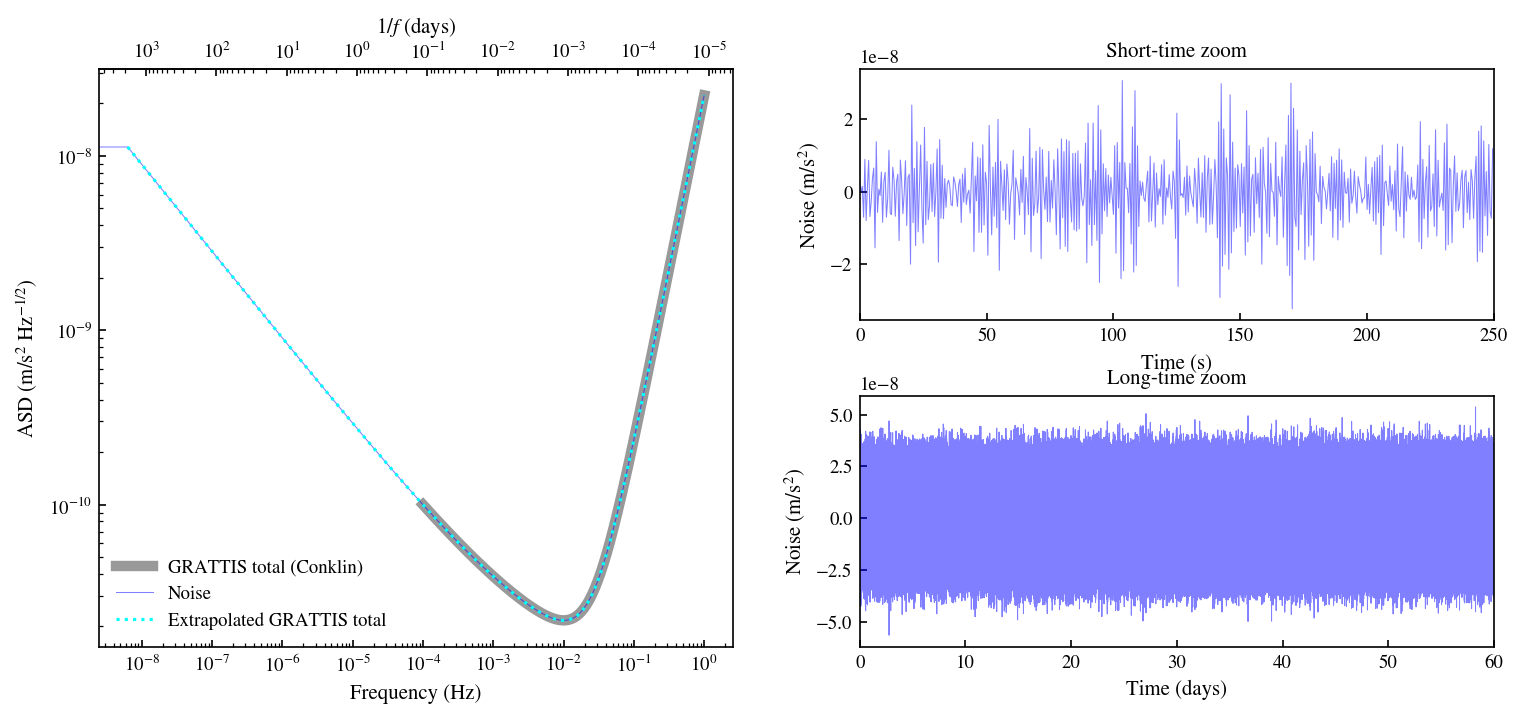

In [5]:
fig = plt.figure(figsize=(12, 5), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1],
                      hspace=0.3, wspace=0.2)

ax_psd = fig.add_subplot(gs[:, 0])
ax_ts1 = fig.add_subplot(gs[0, 1])
ax_ts2 = fig.add_subplot(gs[1, 1])

ax_psd.loglog(f_vec_grattis_paper, asd_grattis_paper, label='GRATTIS total (Conklin)', lw=5, color='k', alpha=0.4)
ax_psd.loglog(freqs_noise, asd_noise, label='Noise', color='b', alpha=0.5, lw=0.5)
ax_psd.loglog(freqs_noise, asd_grattis, label='Extrapolated GRATTIS total', linestyle=':', color='cyan')
ax_psd.set_xlabel('Frequency (Hz)')
ax_psd.set_ylabel('ASD (m/s$^2$ Hz$^{-1/2}$)')
ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
ax_top_1.set_xlabel('1/$f$ (days)')
ax_psd.legend()

ax_ts1.plot(t_vec[:500], noise[:500], color='b', lw=0.5, alpha=0.5)
ax_ts1.set_ylabel('Noise (m/s$^2$)')
ax_ts1.set_xlabel('Time (s)')
ax_ts1.set_title('Short-time zoom')
ax_ts1.set_xlim([t_vec[0], t_vec[500]])

t_vec_days = t_vec / (24*3600)
t_max = np.min([60, np.max(t_vec_days)])
t_max_idx = np.abs(t_vec_days - t_max).argmin()
ax_ts2.plot(t_vec_days[:t_max_idx], noise[:t_max_idx], color='b', lw=0.5, alpha=0.5)
ax_ts2.set_xlabel('Time (days)')
ax_ts2.set_ylabel('Noise (m/s$^2$)')
ax_ts2.set_title('Long-time zoom')
ax_ts2.set_xlim([t_vec_days[0], t_vec_days[t_max_idx]])

plt.tight_layout()
plt.show()

Getting output variable: srp
Getting output variable: srp
Getting output variable: srp
Getting output variable: erp
Getting output variable: erp
Getting output variable: erp
Getting output variable: aero
Getting output variable: aero
Getting output variable: aero
Getting output variable: jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Subsampling time hist: orig. shape: (51840,); downsample_fact=30
Subsampling time hist: final shape: (1727,)
Subsampling time hist: orig. shape: (51840,); downsample_fact=30
Subsampling time hist: final shape: (1727,)


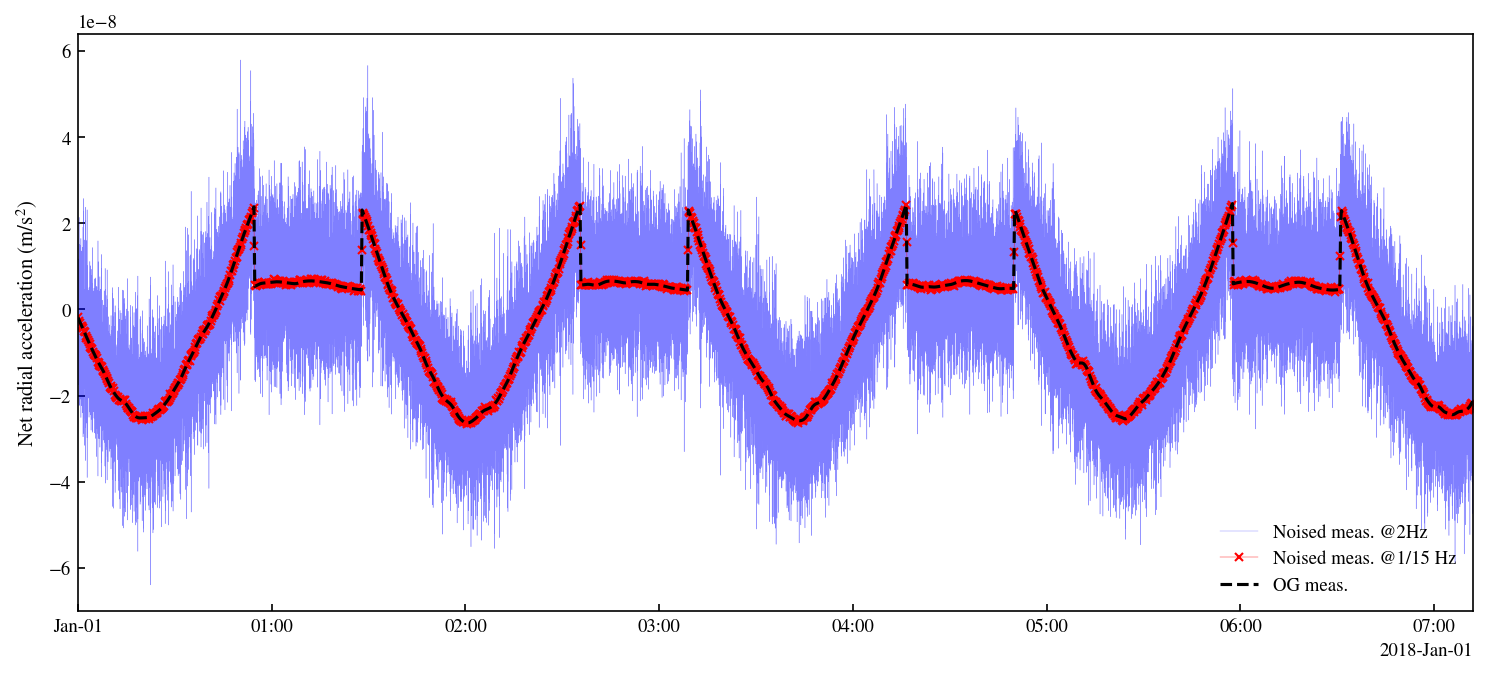

In [6]:
from SpaceBalls.postproc_EEI_estimation import get_radial_measurements_array, get_full_output_var_hist
from SpaceBalls.utils import nanrms, normal_smoother, downsample_array
#from SpaceBalls.plotter import Plotter
#import matplotlib.pyplot as plt
#import numpy as np

mode = "monte" # "monte"
input_names = ['32c08b39a7c5dce2', '7b54acc8701b0625', '82c0c7e77260bb76'] 
acc_meas_radial = get_radial_measurements_array(input_names, meas="acceleration")
jd_vecs =  get_full_output_var_hist(input_names, 'jd_vec')

sb_idx = 2
n_days = 0.3
step_days = np.mean(np.diff(jd_vecs[sb_idx]))
max_idx = int(np.round(n_days / step_days))
acc_meas_short = acc_meas_radial[sb_idx][:max_idx]
jd_vec_short = jd_vecs[sb_idx][:max_idx]
t_vec_meas_short = (jd_vec_short - jd_vec_short[0]) * 24 * 3600

fs = 2 # Hz
f_ds = int(1/fs /dt) # downsampling factor: dt desired / dt original
noise_fs = noise[::f_ds]
t_vec_fs = t_vec[::f_ds]

step_days_noise = (1/fs) / (24 * 3600)
max_idx = int(np.round(n_days / step_days_noise))
noise_short = noise_fs[:max_idx]
t_vec_short = t_vec_fs[:max_idx]
acc_meas_at_noise_times = np.interp(t_vec_short, t_vec_meas_short, acc_meas_short)
jd_vec_fine = jd_vec_short[0] + t_vec_short/(24*3600)

fS = 1/15
acc_meas_with_noise = acc_meas_at_noise_times + noise_short
acc_meas_with_noise_smooth = normal_smoother(acc_meas_with_noise, t_vec_short, 1/fS, out_length_mode='same_with_nans')
#f_ds = int(1/fS / (1/fs)) # downsampling factor: dt desired / dt original
acc_meas_with_noise_smooth_fS = downsample_array(acc_meas_with_noise_smooth, dt, 1/fS) #acc_meas_with_noise_smooth[::f_ds]
jd_vec_fine_fS = downsample_array(jd_vec_fine, dt, 1/fS) # jd_vec_fine[::f_ds]

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(Plotter.jd_to_datetime(jd_vec_fine), acc_meas_with_noise, label=f"Noised meas. @{fs}Hz", color='b', lw=0.2, alpha=0.5)
ax.plot(Plotter.jd_to_datetime(jd_vec_fine_fS), acc_meas_with_noise_smooth_fS, label=f"Noised meas. @1/{int(1/fS)} Hz", color='r', lw=0.2, marker='x')
ax.plot(Plotter.jd_to_datetime(jd_vec_fine), acc_meas_at_noise_times, label='OG meas.', color='k', linestyle='--')
ax.set_xlim([Plotter.jd_to_datetime(jd_vec_fine[0]), Plotter.jd_to_datetime(jd_vec_fine[-1])])
ax.set_ylabel('Net radial acceleration (m/s$^2$)')
Plotter.format_time_labels(ax)
ax.legend()

#Plotter.plot_time_series(jd_vec_fine, {'meas': acc_meas_at_noise_times}, ylabel='Radial acc.', f_width=2.5)

Text(0.02, 0.95, 'RMS: $2.42282e-10$ m/s$^2$')

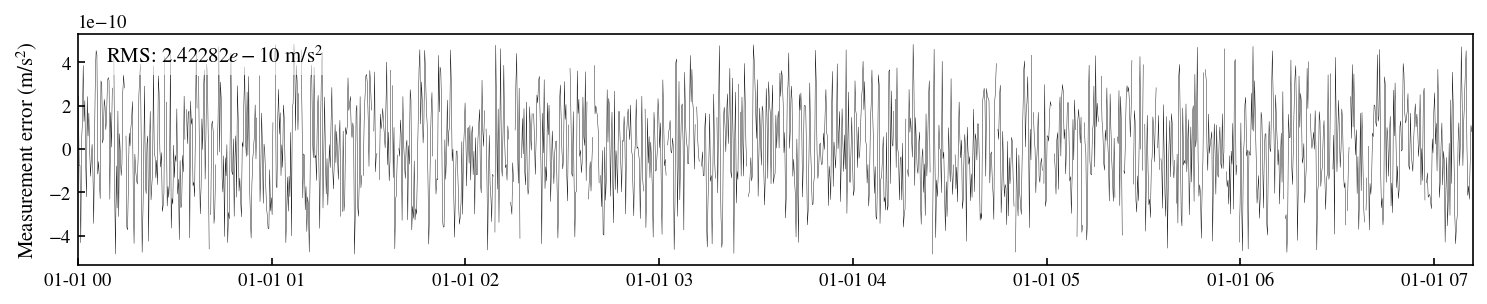

In [7]:

fig, ax = plt.subplots(figsize=(12,2))
truth_at_meas_times = np.interp(jd_vec_fine_fS, jd_vec_fine, acc_meas_at_noise_times)
error = acc_meas_with_noise_smooth_fS - truth_at_meas_times
rms = nanrms(error)
error[np.abs(error)>2*rms] = np.nan

ax.plot(Plotter.jd_to_datetime(jd_vec_fine_fS), error, color='k', lw=0.2)
ax.set_xlim([Plotter.jd_to_datetime(jd_vec_fine[0]), Plotter.jd_to_datetime(jd_vec_fine[-1])])
ax.set_ylabel('Measurement error (m/s$^2$)')
ax.text(
    0.02, 0.95,
    f"RMS: ${rms:.5e}$ m/s$^2$",
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.6
    )
)
#Plotter.format_time_labels(ax)
#ax.set_ylim([-2*rms, 2*rms])

In [8]:
error_no_nan = error.copy()
error_no_nan[np.isnan(error)] = 0.0
X = scipy.fft.rfft(error_no_nan)
freqs = scipy.fft.rfftfreq(len(error_no_nan), 1/fS)
psd, asd_error = fft_to_power(X, len(error_no_nan), 1/fS)

Text(0.02, 0.95, 'RMS: $2.46372e-10$ m/s$^2$')

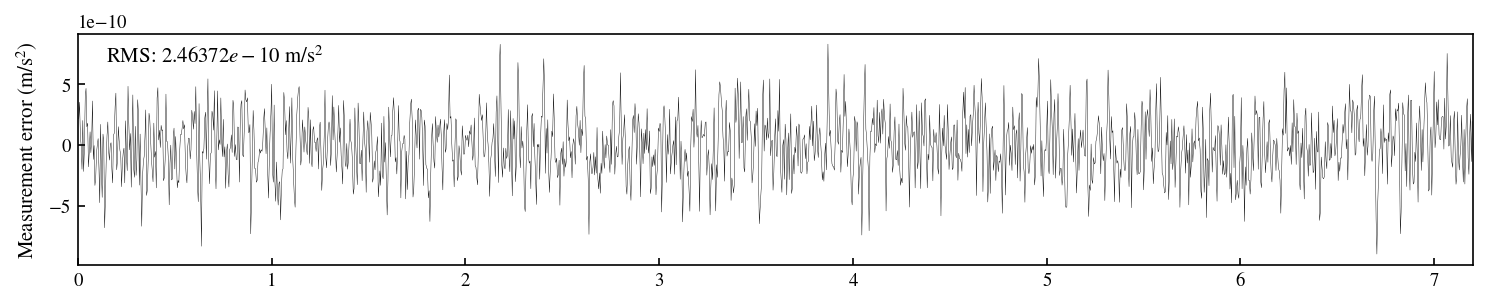

In [9]:

noise_smooth = normal_smoother(noise, t_vec, 1/fS, out_length_mode='same_with_nans')
fig, ax = plt.subplots(figsize=(12,2))

f_ds = int((1/fS) / dt)
noise_smooth_fS = noise_smooth[::f_ds]
t_vec_fS = t_vec[::f_ds]
rms = nanrms(noise_smooth_fS)


step_days = 1/fS /(24*3600)
max_idx = int(np.round(n_days / step_days))

ax.plot(t_vec_fS[:max_idx] / (3600), noise_smooth_fS[:max_idx], color='k', lw=0.2) #, alpha=0.3)
ax.set_xlim([t_vec_fS[0] / (3600), t_vec_fS[max_idx] / (3600)])
ax.set_ylabel('Measurement error (m/s$^2$)')
ax.text(
    0.02, 0.95,
    f"RMS: ${rms:.5e}$ m/s$^2$",
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.6
    )
)

In [ ]:
np.save('noise_example', noise_ smooth_fS)

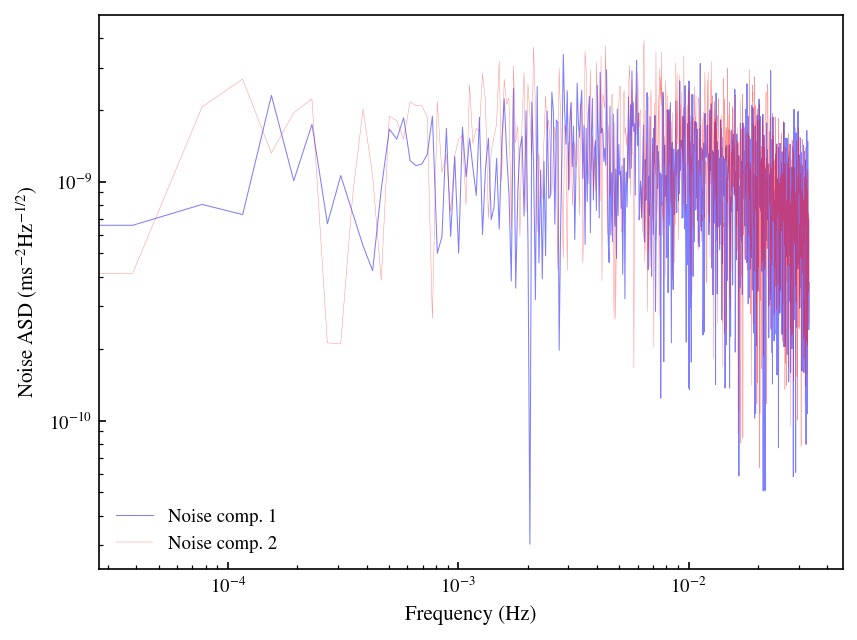

In [10]:
error_no_nan = noise_smooth_fS[:max_idx].copy()
error_no_nan[np.isnan(noise_smooth_fS[:max_idx])] = 0.0
X = scipy.fft.rfft(error_no_nan)
freqs2 = scipy.fft.rfftfreq(len(error_no_nan), 1/fS)
psd, asd_error_simpl = fft_to_power(X, len(error_no_nan), 1/fS)

plt.loglog(freqs, asd_error, lw=0.5, alpha=0.5, color='b', label='Noise comp. 1')
plt.loglog(freqs2, asd_error_simpl, lw=0.2, alpha=0.5, color='r', label='Noise comp. 2')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Noise ASD (ms$^{-2}$Hz$^{-1/2}$)')
plt.legend()

In [ ]:
T_years = 1.5
dt = 0.5
spin_f = 1e-2

t_vec, noise_x = generate_noise_time_series(T_years, dt)
t_vec, noise_y = generate_noise_time_series(T_years, dt)
noise_r = noise_x * np.cos(2*np.pi*spin_f * t_vec) + noise_y * np.sin(2*np.pi*spin_f * t_vec)
    

X_noise_x = scipy.fft.rfft(noise_x)                          # [m/s^2]
X_noise_y = scipy.fft.rfft(noise_y)
freqs_noise = scipy.fft.rfftfreq(len(noise_x), dt)   
_, asd_noise_x = fft_to_power(X_noise_x, len(noise_x), dt)
_, asd_noise_y = fft_to_power(X_noise_y, len(noise_x), dt)
asd_grattis = noise_asd_grattis(freqs_noise)


fig_psd, ax_psd = plt.subplots(figsize=(4.5,2.25))

ax_psd.loglog(f_vec_grattis_paper, asd_grattis_paper, label='GRATTIS total (Conklin)', lw=5, color='k', alpha=0.4)
ax_psd.loglog(freqs_noise, asd_noise_x, label='Noise X', color='b', alpha=0.5)
ax_psd.loglog(freqs_noise, asd_noise_y, label='Noise Y', color='r', alpha=0.5)
#ax_psd.loglog(freqs_noise, asd_grattis, label='Extrapolated GRATTIS total', linestyle=':', color='cyan')
ax_psd.set_xlabel('Frequency (Hz)')
ax_psd.set_ylabel('ASD (m/s$^2$ Hz$^{-1/2}$)')
ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
ax_top_1.set_xlabel('1/$f$ (days)')
ax_psd.legend()

ax_ts1.plot(t_vec[:500], noise_x[:500], color='b', lw=0.5, alpha=0.5, label='Noise X')
ax_ts1.plot(t_vec[:500], noise_y[:500], color='r', lw=0.5, alpha=0.5, label='Noise Y')
ax_ts1.set_ylabel('Noise (m/s$^2$)')
ax_ts1.set_xlabel('Time (s)')
ax_ts1.set_title('Short-time zoom')
ax_ts1.set_xlim([t_vec[0], t_vec[500]])
ax_ts1.legend()

t_vec_days = t_vec / (24*3600)
t_max = np.min([60, np.max(t_vec_days)])
t_max_idx = np.abs(t_vec_days - t_max).argmin()
ax_ts2.plot(t_vec_days[:t_max_idx], noise_x[:t_max_idx], color='b', lw=0.5, alpha=0.5, label='Noise X')
ax_ts2.plot(t_vec_days[:t_max_idx], noise_y[:t_max_idx], color='r', lw=0.5, alpha=0.5, label='Noise Y')
ax_ts2.set_xlabel('Time (days)')
ax_ts2.set_ylabel('Noise (m/s$^2$)')
ax_ts2.set_title('Long-time zoom')
ax_ts2.set_xlim([t_vec_days[0], t_vec_days[t_max_idx]])
ax_ts2.legend(ncols=2)

plt.tight_layout()
plt.show()

NameError: name 'generate_noise_time_series' is not defined

KeyboardInterrupt: 

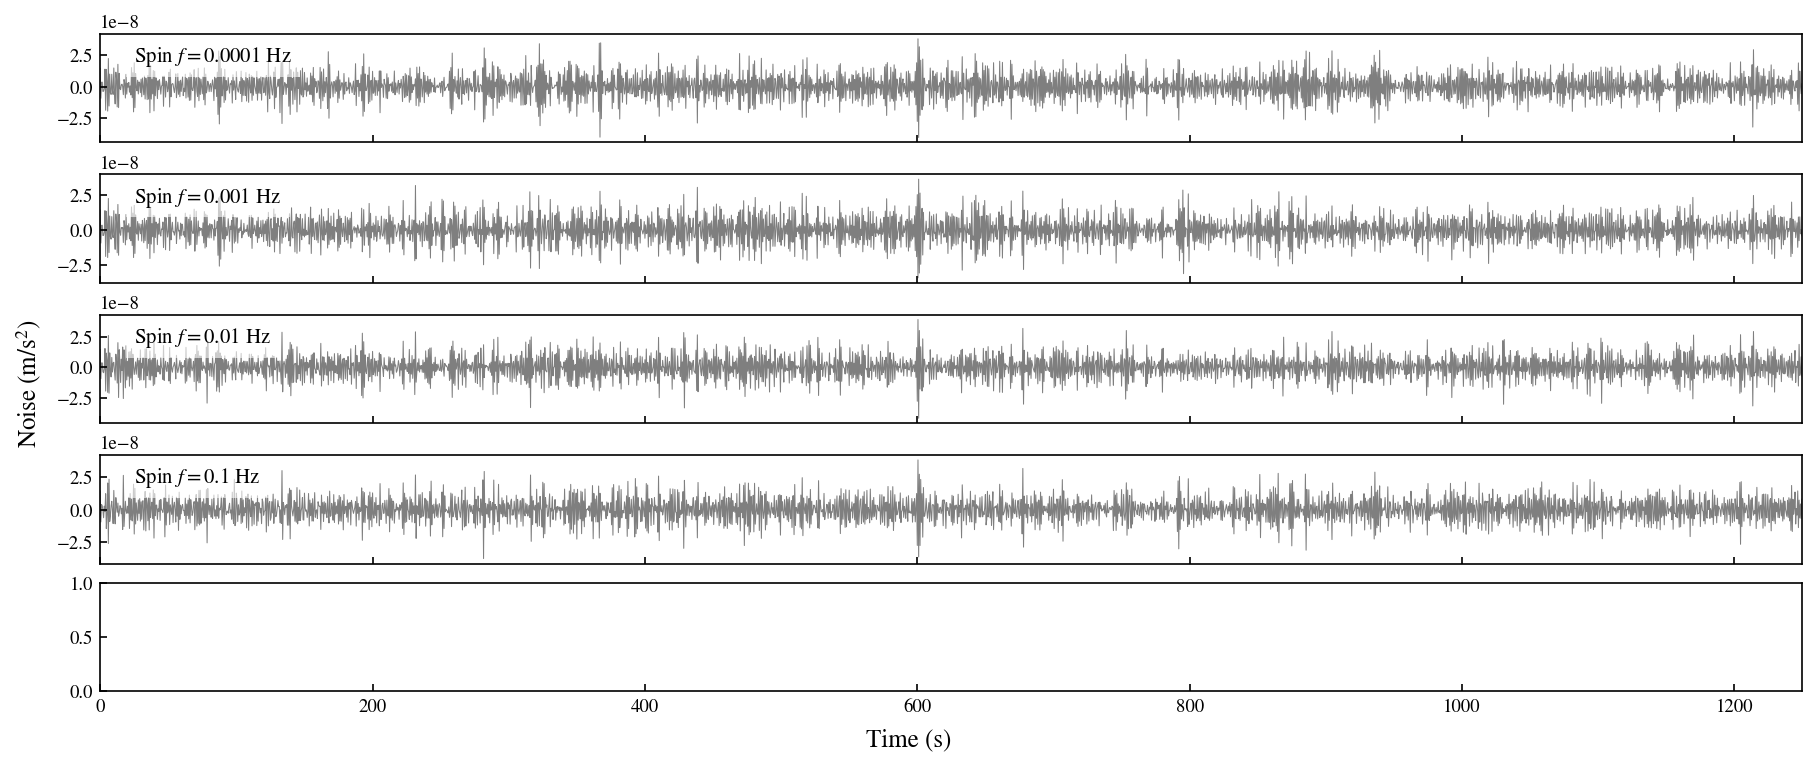

In [12]:
n = 5
spins = np.logspace(-4, 0, n)
fig, axes = plt.subplots(n, 1, sharex=True, figsize=(12,5), layout="constrained")
axes = axes.flatten()   # easier indexing

for i, spin_f in enumerate(spins):
    ax = axes[i]
    noise_r = noise_x * np.cos(2*np.pi*spin_f * t_vec) + noise_y * np.sin(2*np.pi*spin_f * t_vec)
    ax.plot(t_vec[:2500], noise_r[:2500], color='k', lw=0.5, alpha=0.5)
    ax.set_xlim([t_vec[0], t_vec[2500]])

    ax.text(
        0.02, 0.9,
        f"Spin $f={spin_f}$ Hz",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6
        )
    )

    fig.supylabel('Noise (m/s$^2$)')
    fig.supxlabel('Time (s)')


In [ ]:
fig, axes = plt.subplots(n, 1, sharex=True, figsize=(9,10), layout="constrained")

spins_flipped = np.flip(spins)
for i, spin_f in enumerate(spins_flipped):
    ax = axes[i]
    noise_r = noise_x * np.cos(2*np.pi*spin_f * t_vec) + noise_y * np.sin(2*np.pi*spin_f * t_vec)
    X_noise_r = scipy.fft.rfft(noise_r)                          # [m/s^2]
    freqs_noise_r = scipy.fft.rfftfreq(len(noise_r), dt)   
    _, asd_noise_r = fft_to_power(X_noise_r, len(noise_r), dt)

    ax.loglog(freqs_noise_r, asd_noise_r, lw=0.5, alpha=0.8, color='b', label='Modulated noise')
    ax.loglog(f_vec_grattis_paper, asd_grattis_paper, label='GRATTIS total (Conklin)', lw=5, color='k', alpha=0.4)
    ax.loglog(freqs_noise, asd_grattis, label='Extrapolated GRATTIS total', linestyle=':', color='k')
    ax.legend()
    ax.set_xlim([freqs_noise_r[0], freqs_noise_r[-1]])

    ax.text(
        0.02, 0.9,
        f"Spin $f={spin_f}$ Hz",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6
        )
    )

#ax.set_xlabel('Frequency (Hz)')
#ax.set_xlabel('Frequency (Hz)')
#ax.set_ylabel('ASD (m/s$^2$ Hz$^{-1/2}$)')
#ax_top_1 = ax.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
#ax_top_1.set_xlabel('1/$f$ (days)')
fig.supylabel('Noise ASD (m/s$^2$ Hz$^{-1/2}$)')
fig.supxlabel('Frequency (Hz)')

#ax.legend()

/tmp/ipykernel_2255948/3440307496.py:15: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([freqs_noise_r[0], freqs_noise_r[-1]])


KeyboardInterrupt: 

In [ ]:
from SpaceBalls.utils import nanrms
fig, axes = plt.subplots(n, 1, figsize=(12,7), layout="constrained")
axes = axes.flatten()   # easier indexing


for i, spin_f in enumerate(spins):
    ax = axes[i]
    noise_r = noise_x * np.cos(2*np.pi*spin_f * t_vec) + noise_y * np.sin(2*np.pi*spin_f * t_vec)
    downsampled_step = 1/spin_f
    downsampling_f = int(downsampled_step / dt)
    downsampled_noise_r = noise_r[::downsampling_f]
    downsampled_t = t_vec[::downsampling_f]
    
    ax.plot(downsampled_t[:4000], downsampled_noise_r[:4000], color='k', lw=0.5, alpha=0.5)
    ax.set_xlim([downsampled_t[0], downsampled_t[4000]])
    print(nanrms(downsampled_noise_r))

    ax.text(
        0.02, 0.9,
        f"Spin $f={spin_f}$ Hz",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6
        )
    )

    fig.supylabel('Noise (m/s$^2$)')
    fig.supxlabel('Time (s)')

In [ ]:
import matplotlib.pyplot as plt
import scipy.fft
from SpaceBalls.postproc_EEI_estimation import get_radial_measurements_array, get_full_output_var_hist
import SpaceBalls.input_database_manager as input_manager

mode = "monte" # "monte"
input_names = ['32c08b39a7c5dce2', '7b54acc8701b0625', '82c0c7e77260bb76'] 
acc_meas_radial = get_radial_measurements_array(input_names, meas="acceleration")
jd_vecs =  get_full_output_var_hist(input_names, 'jd_vec')


fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10,9), layout="constrained")
axes = axes.flatten() 

for i in range(len(input_names)):

    x = acc_meas_radial[i]
    t = jd_vecs[i] * 24 * 3600
    dt = np.mean(np.diff(t))

    N=len(x)
    X = scipy.fft.rfft(x)                       # [m/s^2]
    freqs = scipy.fft.rfftfreq(N, dt)   
    _, asd = fft_to_power(X, N, dt)

    ax = axes[i]
    ax.loglog(freqs, asd, lw=0.5, alpha=0.5, color='b', label='Radial acceleration signal')
    ax.loglog(f_vec_grattis_paper, asd_grattis_paper, label='GRATTIS total (Conklin)', lw=5, color='k', alpha=0.4)
    
    ax.set_xlim([freqs[0], np.max([f_vec_grattis_paper[-1], freqs[-1]])])
    ax.legend()

    if i==0:
        ax_top_1 = ax.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
        ax_top_1.set_xlabel('1/$f$ (days)')

    orbit_i = input_manager.get_dicts(input_names[i])['orbit']['i_0']
    print(orbit_i)

    ax.text(
        0.02, 0.95,
        f"Orbit $i={orbit_i}$ deg.",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6
        )
    )

fig.supylabel('ASD (ms$^{-2}$Hz$^{-1/2}$)')
fig.supxlabel('Frequency (Hz)')
        

In [ ]:
from SpaceBalls.plotter import Plotter
acc_meas_radial = get_radial_measurements_array(input_names, meas="acceleration", meas_mode="recomp_radial")
jd_vecs =  get_full_output_var_hist(input_names, 'jd_vec')
downsampled_step = 15
downsampling_f = int(downsampled_step / dt)
steps_plot = 1500


fig, axes = plt.subplots(n, 1, sharex=True, figsize=(12,10), layout="constrained")
axes = axes.flatten()   # easier indexing

for i, spin_f in enumerate(spins):
    ax = axes[i]
    noise_r = noise_x * np.cos(2*np.pi*spin_f * t_vec) + noise_y * np.sin(2*np.pi*spin_f * t_vec)

    downsampled_noise_r = noise_r[::downsampling_f]
    downsampled_t = t_vec[::downsampling_f]

    meas = acc_meas_radial[2][:steps_plot]
    meas_noised = meas + downsampled_noise_r[:steps_plot]
    
    ax.plot(Plotter.jd_to_datetime(jd_vecs[2][:steps_plot]), meas_noised[:steps_plot], color='k', lw=0.5, alpha=0.5)
    ax.plot(Plotter.jd_to_datetime(jd_vecs[2][:steps_plot]), meas[:steps_plot], color='b')

    ax.set_xlim([Plotter.jd_to_datetime(jd_vecs[2][0]), Plotter.jd_to_datetime(jd_vecs[2][steps_plot])])
    print(nanrms(downsampled_noise_r))

    ax.text(
        0.02, 0.9,
        f"Spin $f={spin_f}$ Hz",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6
        )
    )

    fig.supylabel('Measured $a_R$ (m/s$^2$)')
    #fig.supxlabel('Time (s)')

In [ ]:
from SpaceBalls.plotter import Plotter
acc_meas_radial = get_radial_measurements_array(input_names, meas="acceleration")
jd_vecs =  get_full_output_var_hist(input_names, 'jd_vec')

spin_f = 1e-1
noise_r = noise_x * np.cos(2*np.pi*spin_f * t_vec) + noise_y * np.sin(2*np.pi*spin_f * t_vec)
downsampled_step = 15
downsampling_f = int(downsampled_step / dt)
downsampled_noise_r = noise_r[::downsampling_f]
downsampled_t = t_vec[::downsampling_f]

acc_meas_radial[2][:1500] = acc_meas_radial[2][:1500] + downsampled_noise_r[:1500]

Plotter.plot_time_series(jd_vecs[2][:1500], {'Signal': acc_meas_radial[2][:1500]},
                         ylabel='Radial acc. (m/s$^2$)', f_width=2, f_height=0.8)

Compare the GRATTIS ASD vs the GRACE-FO form given by Kornfield et al. 2019. Freq. range is the same as in Conklin's Fig. 3, although the mathematical expressions allow to extrapolate to any larger or smaller frequencies

In [ ]:
f_min = 1e-4
f_max = 1
f_vec = np.logspace(np.log10(f_min), np.log10(f_max), 300) # Hz

# from that GRACE paper
sqrt_PSD_x = np.sqrt(1 + (f_vec/0.5)**4 + (0.1/f_vec)) * 1e-9
sqrt_PSD_yz = np.sqrt(1 + (f_vec/0.5)**4 + (0.005/f_vec)) * 1e-10

# from Conklin's paper
total_grattis = noise_asd_grattis(f_vec)

plt.loglog(f_vec, sqrt_PSD_x, label='GRACE-FO X axis')
plt.loglog(f_vec, sqrt_PSD_yz, label='GRACE-FO YZ axes')
plt.loglog(f_vec, total_grattis, label='GRATTIS paper total')
plt.xlabel('Frequency (Hz)')
plt.ylabel('ASD (ms$^{-2}$Hz$^{-1/2}$)')
plt.legend()


Now let's create a purely Gaussian noise time series to begin with. We sample one point every 0.5 seconds for 5 years

In [ ]:
dt = 0.5                                    # [sec]
N = int(5 * 365 * 24 * 60 * 60 / dt)        # []
t_vec = np.arange(0, N*dt, dt)              # [sec]
x = np.random.randn(N)                      # [m/s^2]

This has a flat(-ish?) spectrum, as seen in the resulting ASD. Note that the max. visible frequency is 1Hz as this is the Nyquist freq from our 0.5 sec sampling

In [ ]:
X_noise = scipy.fft.rfft(x)                         # [m/s^2]
freqs = scipy.fft.rfftfreq(N, dt)                   # [Hz]

power_noise = (np.abs(X_noise))**2 / (N**2)             # [m^2/s^4]
power_noise[1:-1] *= 2.0   # one-sided            # [m^2/s^4]
psd_noise = power_noise * N * dt                        # [m^2/s^3] = [m^2/(s^4*Hz)]
asd_noise = np.sqrt(psd_noise)                          # [m/(s^2*Hz^(-1/2))]

plt.loglog(freqs, asd_noise)
plt.xlabel('Frequency (Hz)')
plt.ylabel('ASD (ms$^{-2}$Hz$^{-1/2}$)')

However, we want this spectrum to look like the reported GRATTIS noise one (i.e., green curve in Fig. 1 above), so we define a transfer function that relates the ASD ratio between the two. Essentially, we want the GRATTIS curves to act as a filter of Gaussian noise

In [ ]:
asd_grattis= noise_asd_grattis(freqs)           # [m/(s^2*Hz^(-1/2))]
asd_grattis[0] = asd_grattis[1]  # we set the ASD value for f=0 to the same as for the smallest nonzero freq., since the function returns ads(f=0)=inf

asd_noise_simpl = np.ones_like(asd_grattis)     # general shape of Gaussian noise spectrum instead of a particular realization
H = asd_grattis / asd_noise               # scalar transfer function. 1 is the spectral 

This allows us to scale the ASD of the purely Gaussian noise:

In [ ]:
X_filtered = X_noise * H

power_filtered = (np.abs(X_filtered))**2 / (N**2)             # [m^2/s^4]
power_filtered[1:-1] *= 2.0   # one-sided            # [m^2/s^4]
psd_filtered = power_filtered * N * dt                        # [m^2/s^3] = [m^2/(s^4*Hz)]
asd_filtered = np.sqrt(psd_filtered)                          # [m/(s^2*Hz^(-1/2))]

plt.loglog(freqs, asd_filtered, label='Resulting noise')
plt.loglog(freqs, asd_grattis, label='Extrapolated GRATTIS total', linestyle='--')
plt.loglog(f_vec, total_grattis, label='GRATTIS paper total', linestyle=':', lw=2, color='g')
plt.xlabel('Frequency (Hz)')
plt.ylabel('ASD (ms$^{-2}$Hz$^{-1/2}$)')
plt.legend()

The resulting noise time series can be obtained by iFFT'ing the resulting noise spectrum

In [ ]:
filtered_noise = scipy.fft.irfft(X_filtered, n=N)

plt.plot(t_vec[:100], filtered_noise[:100])
plt.xlabel('Time (s)')
plt.ylabel('Noise (m/s$^2$)')

In [ ]:
np.sqrt(np.mean(filtered_noise**2))

In [ ]:
np.std(filtered_noise)

Note how the time series still behaves jitterly because we have not filtered the high frequencies of the spectrum

In [ ]:
plt.plot(t_vec[:100000000]/3600, filtered_noise[:100000000])
plt.xlabel('Time (h)')
plt.ylabel('Noise (m/s$^2$)')

In [ ]:
downsampled_step = 100
downsampling_f = int(downsampled_step / dt)
downsampled_noise = filtered_noise[::downsampling_f]
downsampled_t = t_vec[::downsampling_f]

plt.plot(downsampled_t[:100], downsampled_noise[:100])
plt.xlabel('Time (s)')
plt.ylabel('Noise (m/s$^2$)')

In [ ]:
plt.plot(downsampled_t[:10000], downsampled_noise[:10000])
plt.xlabel('Time (s)')
plt.ylabel('Noise (m/s$^2$)')

In [ ]:
# testing spinning
f_spin = 1e-3       # [Hz]
x = np.sin(2*np.pi * f_spin * t_vec)

X = scipy.fft.rfft(x)                       # [m/s^2]
freqs = scipy.fft.rfftfreq(N, dt)           # [Hz]

power = (np.abs(X))**2 / (N**2)             # [m^2/s^4]
power[1:-1] *= 2.0   # one-sided            # [m^2/s^4]
psd = power * N * dt                        # [m^2/s^3] = [m^2/(s^4*Hz)]
asd = np.sqrt(psd)                          # [m/(s^2*Hz^(-1/2))]

plt.loglog(freqs, asd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('ASD (Hz$^{-1/2}$)')